# Empirical Fluctuations of OT, MMD, and Sinkhorn Divergences

This notebook generates `fig:sinkhorn-bias-variance-tradeoff`.  It draws a small statistical experiment rather than a solver benchmark: for each sample size $n$, two independent empirical measures
$$
\alpha_n=\frac1n\sum_{i=1}^n\delta_{X_i},\qquad
\alpha'_n=\frac1n\sum_{i=1}^n\delta_{Y_i},
\qquad X_i,Y_i\sim\mathcal N(0,I_d),\quad d\in\{3,6\},
$$
are compared with exact $\mathcal W_2$, a fixed-$\varepsilon$ Sinkhorn divergence, and a Gaussian-kernel MMD.  The goal is to make visible the qualitative sample-complexity message: exact OT keeps dimension-dependent empirical fluctuations, while smoother discrepancies behave more like averages of bounded features.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    LIGHT_GRAY,
    box_axes,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "sinkhorn-bias-variance-tradeoff"
OUT = figure_dir(NAME)

RNG = np.random.default_rng(43)
DIMENSIONS = (3, 6)
N_VALUES = np.array([16, 24, 36, 54, 81, 120, 180])
N_REPETITIONS = 16
SINKHORN_EPSILON_PER_DIMENSION = {3: 2.0, 6: 3.6}
MMD_SIGMA_PER_DIMENSION = {3: 2.0, 6: 2.8}


## Discrepancies

All costs use $c(x,y)=\|x-y\|^2$.  We plot distance-like square roots for $\mathcal W_2^2$, for the debiased Sinkhorn divergence
$$
S_\varepsilon(\alpha,\beta)
= \mathrm{OT}_\varepsilon(\alpha,\beta)
-\frac12\mathrm{OT}_\varepsilon(\alpha,\alpha)
-\frac12\mathrm{OT}_\varepsilon(\beta,\beta),
$$
and for the biased empirical MMD$^2$ associated with the Gaussian kernel.  The plotted vertical scale is normalized by the first median value so that the slopes, rather than the arbitrary units of each discrepancy, can be compared.

In [2]:
def squared_distances(x, y):
    return ot.dist(x, y, metric="sqeuclidean")


def uniform_weights(n):
    return np.full(n, 1.0 / n)


def wasserstein_distance(x, y):
    n = len(x)
    weights = uniform_weights(n)
    cost = squared_distances(x, y)
    return np.sqrt(max(float(ot.emd2(weights, weights, cost)), 0.0))


def entropic_ot_cost(x, y, epsilon):
    a = uniform_weights(len(x))
    b = uniform_weights(len(y))
    cost = squared_distances(x, y)
    return float(
        ot.sinkhorn2(
            a,
            b,
            cost,
            reg=epsilon,
            numItermax=600,
            stopThr=1e-8,
            warn=False,
        )
    )


def sinkhorn_distance(x, y, epsilon):
    value = entropic_ot_cost(x, y, epsilon)
    value -= 0.5 * entropic_ot_cost(x, x, epsilon)
    value -= 0.5 * entropic_ot_cost(y, y, epsilon)
    return np.sqrt(max(value, 0.0))


def mmd_distance(x, y, sigma):
    cxy = squared_distances(x, y)
    cxx = squared_distances(x, x)
    cyy = squared_distances(y, y)
    kxy = np.exp(-cxy / (2.0 * sigma**2))
    kxx = np.exp(-cxx / (2.0 * sigma**2))
    kyy = np.exp(-cyy / (2.0 * sigma**2))
    value = kxx.mean() + kyy.mean() - 2.0 * kxy.mean()
    return np.sqrt(max(value, 0.0))


## Small Monte Carlo experiment

For each dimension, the experiment uses the same Gaussian law for the two samples.  The value being measured is therefore a pure empirical fluctuation: it should converge to zero as $n$ grows.  The interquartile bands are deliberately shown to remind the reader that these are random empirical discrepancies, not deterministic asymptotic curves.

In [3]:
values_by_dimension = {}

for dimension in DIMENSIONS:
    rng = np.random.default_rng(4300 + dimension)
    epsilon = SINKHORN_EPSILON_PER_DIMENSION[dimension]
    sigma = MMD_SIGMA_PER_DIMENSION[dimension]
    values = {
        "ot": np.zeros((len(N_VALUES), N_REPETITIONS)),
        "sinkhorn": np.zeros((len(N_VALUES), N_REPETITIONS)),
        "mmd": np.zeros((len(N_VALUES), N_REPETITIONS)),
    }
    for i, n in enumerate(N_VALUES):
        for r in range(N_REPETITIONS):
            x = rng.normal(size=(n, dimension))
            y = rng.normal(size=(n, dimension))
            values["ot"][i, r] = wasserstein_distance(x, y)
            values["sinkhorn"][i, r] = sinkhorn_distance(x, y, epsilon)
            values["mmd"][i, r] = mmd_distance(x, y, sigma)
    values_by_dimension[dimension] = values


## Log-log display

Each panel shows the dimension-dependent guide $n^{-1/d}$ and the parametric guide $n^{-1/2}$.  The former is the qualitative scale associated with exact OT in high dimension, while the latter is the scale expected for smoother kernel-like discrepancies at fixed regularization.

In [4]:
def normalized_quantiles(samples):
    median = np.median(samples, axis=1)
    q25, q75 = np.quantile(samples, [0.25, 0.75], axis=1)
    scale = median[0]
    return median / scale, q25 / scale, q75 / scale


series = [
    ("ot", r"$\mathcal{W}_2$", RED),
    ("sinkhorn", r"$S_\varepsilon^{1/2}$", VIOLET),
    ("mmd", r"$\mathrm{MMD}$", BLUE),
]


def draw_dimension_panel(dimension, filename):
    values = values_by_dimension[dimension]
    fig, ax = plt.subplots(figsize=(2.70, 2.18))

    for key, label, color in series:
        median, q25, q75 = normalized_quantiles(values[key])
        ax.fill_between(N_VALUES, q25, q75, color=color, alpha=0.13, linewidth=0)
        ax.loglog(
            N_VALUES,
            median,
            color=color,
            lw=1.25,
            marker="o",
            markersize=2.7,
            markeredgewidth=0,
            label=label,
            zorder=3,
        )

    guide_n = np.array([N_VALUES[1], N_VALUES[-1]])
    dim_slope = -1.0 / dimension
    ax.loglog(guide_n, 1.03 * (guide_n / guide_n[0]) ** dim_slope, color=GRAY, lw=0.8, ls="--", alpha=0.70)
    ax.loglog(guide_n, 0.60 * (guide_n / guide_n[0]) ** (-1 / 2), color=GRAY, lw=0.8, ls=":", alpha=0.78)
    ax.text(105, 0.97 * (105 / guide_n[0]) ** dim_slope, rf"$n^{{-1/{dimension}}}$", color=GRAY, fontsize=7.0)
    ax.text(108, 0.60 * (108 / guide_n[0]) ** (-1 / 2) * 0.93, r"$n^{-1/2}$", color=GRAY, fontsize=7.0)

    ax.set_xlabel(r"sample size $n$")
    ax.set_ylabel(r"relative discrepancy")
    ax.set_xlim(N_VALUES[0] * 0.86, N_VALUES[-1] * 1.12)
    ax.set_ylim(0.23, 1.24)
    ax.grid(True, which="both", color=LIGHT_GRAY, lw=0.42, alpha=0.58)
    ax.legend(frameon=False, fontsize=6.8, handlelength=1.5, loc="lower left")
    box_axes(ax)
    fig.tight_layout(pad=0.15)
    save_pdf(fig, OUT / filename, pad_inches=0.055)
    plt.close(fig)


for dimension in DIMENSIONS:
    draw_dimension_panel(dimension, f"dimension-{dimension}.pdf")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


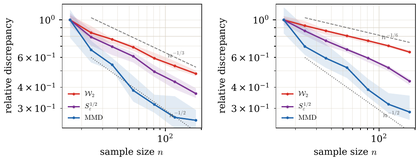

In [5]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-bias-variance-tradeoff.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-bias-variance-tradeoff.png")
display(Image(filename=str(_thumb)))
